In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ctw.models import BivariateQuantizer
import numpy as np

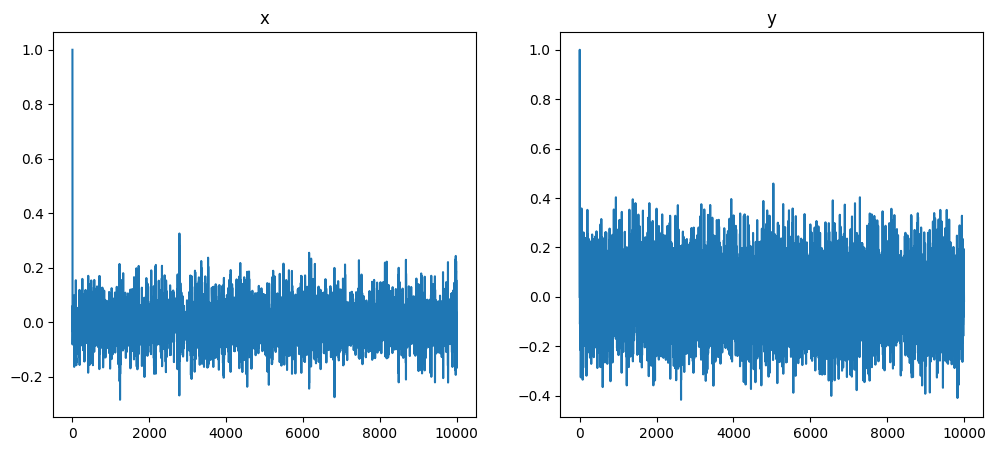

In [3]:
import numpy as np

## Parameters
n_samples = 10000
order = 2
max_depth = 3

positive_ar_coeff = [1, -0.1]
positive_var = 0.01

negative_ar_coeff = [-0.5, 0.5]
negative_var = 0.05

ar_coeff_y = [0.7, -0.3]
var_y = 0.1

def generate_dual_ar(init_seq_x, init_seq_y, n_samples) :
    x = init_seq_x[:]
    y = init_seq_y[:]
    for _ in range(n_samples) :
        if y[-1] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
        
        y.append(ar_coeff_y[0]*y[-1] + ar_coeff_y[1]*y[-2] + np.random.normal(0, var_y))

    return x, y

seq_x, seq_y = generate_dual_ar(init_seq_x = [1, 0], init_seq_y = [0, 1], n_samples=n_samples)
thresholds = np.concatenate([[0, 100], 
                             [0,100]], axis = 0).reshape(2, -1)

# Plot x and y
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(seq_x)
plt.title("x")
plt.subplot(1, 2, 2)
plt.plot(seq_y)
plt.title("y");


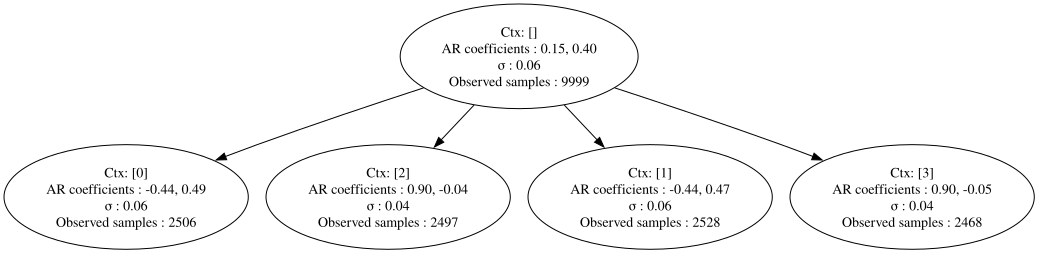

In [4]:
from ctw.models import BivariateQuantizer, BivariateARTree
from ctw.tree import view_tree
bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq)
for x, y in zip(seq_x, seq_y) :
    tree.observe(x, y)

view_tree(tree.tree)


## Prediction with the shallow data

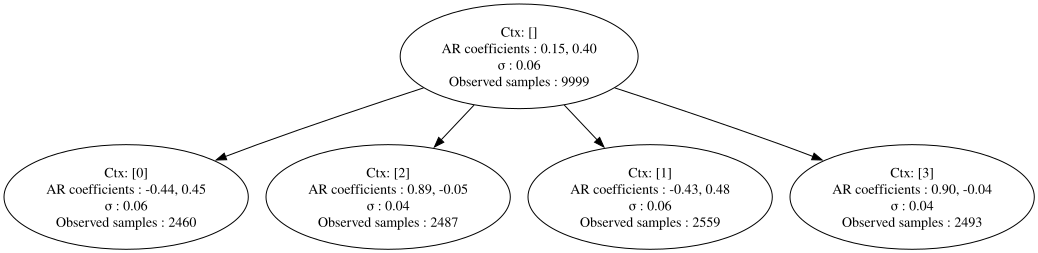

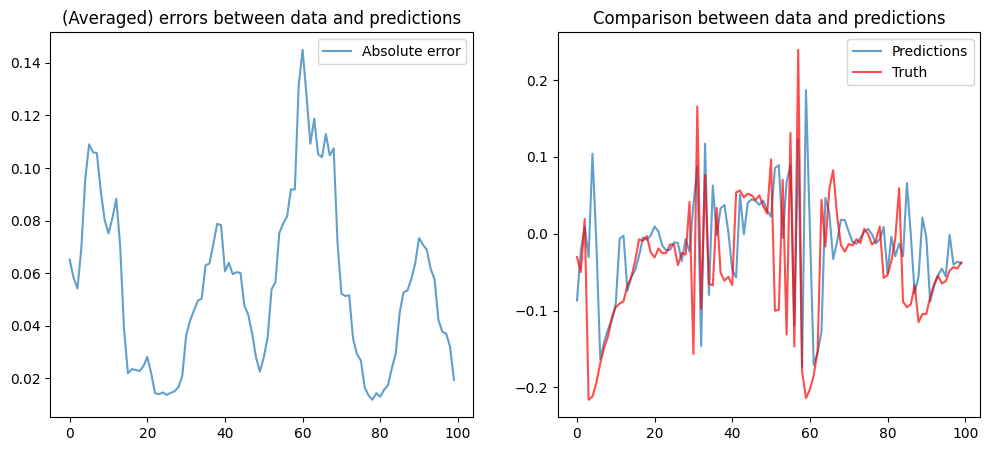

In [5]:
## Parameters
n_samples = 10000
order = 2
max_depth = 3

positive_ar_coeff = [1, -0.1]
positive_var = 0.01

negative_ar_coeff = [-0.5, 0.5]
negative_var = 0.05

ar_coeff_y = [0.7, -0.3]
var_y = 0.1


seq_x, seq_y = generate_dual_ar(init_seq_x = [1, 0], init_seq_y = [0, 1], n_samples=n_samples)
thresholds = np.concatenate([[0, 100], 
                             [0,100]], axis = 0).reshape(2, -1)

bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq)

for x, y in zip(seq_x[:order], seq_y[:order]) :
    tree.observe(x, y)

# Draw error curve between predicted and actual values
predictions = []
actuals = []
for x_i, y_i in zip(seq_x[order:], seq_y[order:]):
    history = np.array([tree._x[-max_depth:], tree._y[-max_depth:]])
    prediction = tree.predict(history)
    predictions.append(prediction)
    actuals.append(x_i)
    tree.observe(x_i, y_i)
    
errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
window = 10  
error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')

data_to_plot = 100

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(error_avg[-data_to_plot:], label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("(Averaged) errors between data and predictions")

plt.subplot(1, 2, 2)
plt.plot(predictions[-data_to_plot:], label = "Predictions", alpha = 0.7)
plt.plot(actuals[-data_to_plot:], label = "Truth", alpha = 0.7, color = "red")
plt.legend()
plt.title("Comparison between data and predictions")

view_tree(tree.tree)